In [1]:
import os, sys
sys.path.append(os.path.join(os.environ.get('IDEFIX_DIR','../../../../'), 'pytools'))

import numpy as np
import matplotlib.pyplot as plt
import dump_io as io

from astropy import constants as const, units as u

from scipy.integrate import solve_ivp

%matplotlib inline


In [2]:
uL = 1e8 *u.cm.cgs
uv = 1e6 *u.cm.cgs/u.s.cgs
ud = 1e0 *u.g.cgs/u.cm.cgs**3
uM = ud*uL**3
ut = (uL/uv).decompose()
uT = ((u.g.cgs/u.mol.cgs) * uv**2 / (const.k_B.cgs * const.N_A.cgs)).decompose()
u_opac = 1/(ud*uL)

mu = 2.353

u_aR = (uM*uv**2/(uL**3 * uT**4)).decompose()
a_rad = ((4*const.sigma_sb/const.c)/u_aR).to_value()

c_l = (const.c / uv).decompose().to_value()
print(c_l, a_rad)

29979.2458 1.5831216377811077e-10


In [ ]:
class DustyFLD:
    """FLD for dust+gas temperatures coupled by radiation and collisions"""

    def __init__(self, cd, kd, gamma, cg=1, kg=1, fd=None, fg=0, fE=0):
        self.cd = cd 
        self.cg = cg

        self.kd = kd 
        self.kg = kg 

        self.fg = fg
        self.fE = fE
        if fd is None: 
            self.fd = np.zeros_like(self.cd)
        else:
            self.fd = fd

        self.gamma = gamma 

    def ode(self, Tg, Td, Erad):
        dTg_dt = (self.fg  + np.sum(self.gamma*(Td-Tg)) + self.kg*c_l*(Erad - a_rad*Tg**4)) / self.cg
        dTd_dt = (self.fd  -        self.gamma*(Td-Tg)  + self.kd*c_l*(Erad - a_rad*Td**4)) / self.cd 
        dEr_dt =  self.fE  - self.kg*c_l*(Erad - a_rad*Tg**4) - np.sum(self.kd*c_l*(Erad - a_rad*Td**4))

        return [dTg_dt, dTd_dt, dEr_dt]

    def implicit_step(self, dt, Tg, Td, Erad):
        lg = 4*a_rad*self.kg*c_l*Tg**3
        ld = 4*a_rad*self.kd*c_l*Td**3

        fg = (self.fg + 0.75*lg*Tg)
        fd = (self.fd + 0.75*ld*Td)
        fE =  self.fE - 0.75*lg*Tg - np.sum(0.75*ld*Td)      
        
        Zd = (self.cd + ld*dt + self.gamma*dt)
        Zg = (self.cg + lg*dt + np.sum(self.gamma*dt*(self.cd + ld*dt)/Zd))

        u_tot = self.cg*Tg + fg*dt + np.sum(self.gamma*dt*(self.cd*Td + fd*dt)/Zd)
        c_tot = self.cg + np.sum(self.gamma*dt*self.cd/Zd)
        k_tot = self.kg + np.sum(self.gamma*dt*self.kd/Zd)
        #l_tot =   lg*dt + np.sum(self.gamma*dt*ld*dt/Zd)

        RHS = Erad + fE*dt + np.sum(ld*dt*(self.cd*Td + fd*dt)/Zd) + \
            (lg*dt + np.sum(ld*dt*self.gamma*dt)/Zd)*u_tot/Zg
 
        NORM = 1 + c_l*dt*(np.sum(self.kd*self.cd/Zd) + k_tot*c_tot/Zg)
        Erad_new = RHS / NORM 


        #print(ld/4, self.gamma, Zd, Zg) 
        #print(k_tot, c_tot, u_tot, l_tot/4)
        #print(self.kg, self.kd)
        #print(RHS)
        #print(dt, c_l, a_rad)
        #raise 1
        Tg_new = (u_tot + k_tot*c_l*dt*Erad_new)/Zg
        Td_new = (self.cd*Td + fd*dt + self.kd*c_l*dt*Erad_new + self.gamma*dt*Tg_new)/Zd

        print(self.cd, 0.75*ld, Td, dt)
        print(self.kd*c_l, Erad_new)
        print(self.gamma, Tg_new, Zd)
        print(Td_new)
        raise 1

        return Tg_new, Td_new, Erad_new

    def solve_implicit(self, times, Tg, Td, Erad):

        t = 0 
        res = []
        for ti in times:
            dt = ti-t 
            Tg, Td, Erad = self.implicit_step(dt, Tg, Td, Erad)
            res.append(np.concatenate([[Tg], np.atleast_1d(Td), [Erad]]))
            t = ti

        return times, np.array(res).T

    def solve_explicit(self, times, Tg, Td, Erad):
        x = np.concatenate([[Tg], np.atleast_1d(Td), [Erad]])
        
        def f(t, x):
            Tg = x[0]
            Td = x[1:-1]
            Erad = x[-1]

            dTg_dt, dTd_dt, dEr_dt = self.ode(Tg, Td, Erad)

            return np.concatenate([[dTg_dt], np.atleast_1d(dTd_dt), [dEr_dt]])

        sol = solve_ivp(f, [0, times.max()], x, t_eval=times, method='BDF', rtol=1e-10)

        return sol.t, sol.y



In [4]:
dirc = 'out/'

def load(dirc=dirc, i=0, var='Vc-RHO', slicer=np.s_[:]): return io.readDump(f'{dirc}/dump.{i:04d}.dmp').data[var].transpose(2,1,0)[slicer][0]
def load3D(dirc=dirc, i=0, var='Vc-RHO', slicer=np.s_[:]): return io.readDump(f'{dirc}/dump.{i:04d}.dmp').data[var].transpose(2,1,0)[slicer]

In [ ]:
def run_and_plot(dirc, analytic=True, **kwargs):
    dmp = io.readDump(f'{dirc}/dump.0000.dmp')

    rho_g = dmp.data['Vc-RHO'][0,0,0] 
    rho_d = dmp.data['Dust0_Vc-RHO'][0,0,0] 

    cd = 0.1*rho_d
    cg = 2.5*rho_g /mu

    kd = 10 * rho_d / u_opac.to_value()
    kg = 1 * rho_g / u_opac.to_value()

    t_s = 1e-13/np.sqrt(1.4*dmp.data['Vc-PRS'][0,0,0]*rho_g)

    gamma = (2.5/mu) * rho_d /t_s

    Tg0 = (mu * dmp.data['Vc-PRS'] / rho_g)[0,0,0]
    Td0 = (dmp.data['Dust0_Vc-TR0'])[0,0,0]
    Tr0 = ((dmp.data['ERAD'] / a_rad)**0.25)[0,0,0]


    results = np.genfromtxt(f'{dirc}/monitoring.txt').T

    if analytic:
        model = DustyFLD(cd, kd, gamma, cg, kg)

        times = np.geomspace(results[0,0], results[0,-1], 1000)
        
        t, y = model.solve_explicit(times, Tg0, Td0, a_rad*Tr0**4)

        plt.plot(t * ut.to_value(), y[0] * uT.to_value(), c='C0', label='Gas')
        plt.plot(t * ut.to_value(), y[1] * uT.to_value(), c='C1', label='Dust')
        plt.semilogx(t * ut.to_value(), (y[2]/a_rad)**0.25 * uT.to_value(), c='C2', label='T_rad')
        plt.legend()
        plt.xlabel('Time [s]')
        plt.ylabel('Temperature [K]')

    plt.plot(results[0] * ut.to_value(), results[3] * uT.to_value(), c='C0', **kwargs)
    plt.plot(results[0] * ut.to_value(), results[4] * uT.to_value(), c='C1', **kwargs)
    plt.plot(results[0] * ut.to_value(), results[5] * uT.to_value(), c='C2', **kwargs)


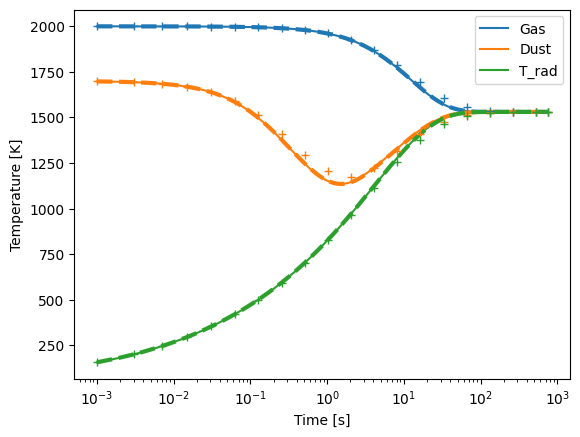

In [6]:
run_and_plot('out', True, ls='--', lw=3)
run_and_plot('out_dt2', False, ls='none', marker='+')

